In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Environment Preparation

In [3]:
from pysimfin import PySimFin

pymsimfin = PySimFin()

In [4]:
companies_df = pd.read_csv('us-companies.csv', sep=';', index_col=0)
shareprices_df = pd.read_csv('us-shareprices-daily.csv', sep=';', parse_dates=['Date'], index_col=0)

In [5]:
companies_df = companies_df[~companies_df.index.isna()]
companies_df.head()

,SimFinId,Company Name,IndustryId,ISIN,End of financial year (month),Number Employees,Business Summary,Market,CIK,Main Currency
Ticker,,,,,,,,,,
A,45846,AGILENT TECHNOLOGIES INC,106001.0,US00846U1016,10.0,16400.0,Agilent Technologies Inc is engaged in life sc...,us,1090872.0,USD
A21,1333027,Li Auto Inc.,NaN,NaN,12.0,NaN,NaN,us,1791706.0,USD
AA,367153,Alcoa Corp,110004.0,US0138721065,12.0,12900.0,Alcoa Corp is an integrated aluminum company. ...,us,1675149.0,USD
AAC,7962652,Ares Acquisition Corporation,104002.0,US0003071083,12.0,NaN,Ares Acquisition Corporation does not have sig...,us,1829432.0,USD
AACI,11820349,Armada Acquisition Corp. I,104002.0,US04208V1035,9.0,NaN,Armada Acquisition Corp. I focuses on effectin...,us,1844817.0,USD


In [6]:
shareprices_df = pymsimfin.get_share_prices('TSLA','2019-01-01','2024-03-31')

In [7]:
print('Percent of Null Values Per Category:\n')
print(shareprices_df.isna().sum()/len(shareprices_df))

Percent of Null Values Per Category:

Ticker                       0.0
SimFinId                     0.0
Date                         0.0
Opening Price                0.0
Highest Price                0.0
Lowest Price                 0.0
Last Closing Price           0.0
Adjusted Closing Price       0.0
Trading Volume               0.0
Dividend Paid                1.0
Common Shares Outstanding    0.0
dtype: float64


In [8]:
shareprices_df.columns

Index(['Ticker', 'SimFinId', 'Date', 'Opening Price', 'Highest Price',
       'Lowest Price', 'Last Closing Price', 'Adjusted Closing Price',
       'Trading Volume', 'Dividend Paid', 'Common Shares Outstanding'],
      dtype='object')

In [9]:
# Drop the columns that have null values and aren't useful
shareprices_df = shareprices_df.drop(columns=['Dividend Paid','Common Shares Outstanding'])

In [10]:
shareprices_df.rename(columns={
    'Opening Price':'Open', 'Highest Price':'High','Lowest Price':'Low','Last Closing Price':'Close','Trading Volume':'Volume'
    
},inplace=True)

shareprices_df['Date'] = pd.to_datetime(shareprices_df['Date'])

In [11]:
df = shareprices_df
df.set_index('Ticker',inplace=True)

**GPT Prompt for Feature Engineering + Next Steps**

Our goal is to use historical daily data from share prices to build a model that:

1) Will predict whether the price will rise or fall
2) Must make predictions daily and predict the one-day-ahead price movement
3) Eventually inform the user on whether they should buy or sell the stock

Our professor who assigned us the project recommended the following approach to processing the data:

1) Feature engineer and create more information with what we already have
2) Assess collinearity and feature importance to reduce the information back down to what's useful
3) Use this engineered dataset with a linear regression model to predict the open or close price based on our set of features

## Feature Engineering

In [12]:
def transformation(df):
    df['Day'] = df['Date'].dt.day
    df['Month'] = df['Date'].dt.month
    df['Year'] = df['Date'].dt.year
    df['DayOfWeek'] = df['Date'].dt.day_of_week
    df['Quarter'] = df['Date'].dt.quarter
    df['DayOfYear'] = df['Date'].dt.dayofyear
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week
    df['SMA_10'] = df['Close'].rolling(window=10).mean()
    df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()

    def compute_rsi(data, window=14):
        delta = data.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))

    df['RSI'] = compute_rsi(df['Close'])

    df['Daily_Return'] = df['Close'].pct_change()
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    
    df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()
    
    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

    df['Rolling_Std_10'] = df['Daily_Return'].rolling(window=10).std()
    df['Rolling_Std_20'] = df['Daily_Return'].rolling(window=20).std()
    df['Rolling_Std_50'] = df['Daily_Return'].rolling(window=50).std()

    df['High-Low'] = df['High'] - df['Low']
    df['High-PrevClose'] = abs(df['High'] - df['Close'].shift(1))
    df['Low-PrevClose'] = abs(df['Low'] - df['Close'].shift(1))

    df['TrueRange'] = df[['High-Low', 'High-PrevClose', 'Low-PrevClose']].max(axis=1)
    df['ATR'] = df['TrueRange'].rolling(window=14).mean()

    df['Volume_MA_10'] = df['Volume'].rolling(window=10).mean()
    df['Volume_MA_20'] = df['Volume'].rolling(window=20).mean()

    return df



In [13]:
df = transformation(df)

In [14]:
## Drop columns that are non-numeric/offer no information about the share price
df = df.drop(columns=['SimFinId','Date'])
df.dtypes

Open                      float64
High                      float64
Low                       float64
Close                     float64
Adjusted Closing Price    float64
Volume                      int64
Day                         int32
Month                       int32
Year                        int32
DayOfWeek                   int32
Quarter                     int32
DayOfYear                   int32
WeekOfYear                 UInt32
SMA_10                    float64
EMA_10                    float64
RSI                       float64
Daily_Return              float64
Log_Return                float64
EMA_12                    float64
EMA_26                    float64
MACD                      float64
Signal_Line               float64
Rolling_Std_10            float64
Rolling_Std_20            float64
Rolling_Std_50            float64
High-Low                  float64
High-PrevClose            float64
Low-PrevClose             float64
TrueRange                 float64
ATR           

In [15]:
df['next_day_close'] = df['Close'].shift(-1)

# Select Features

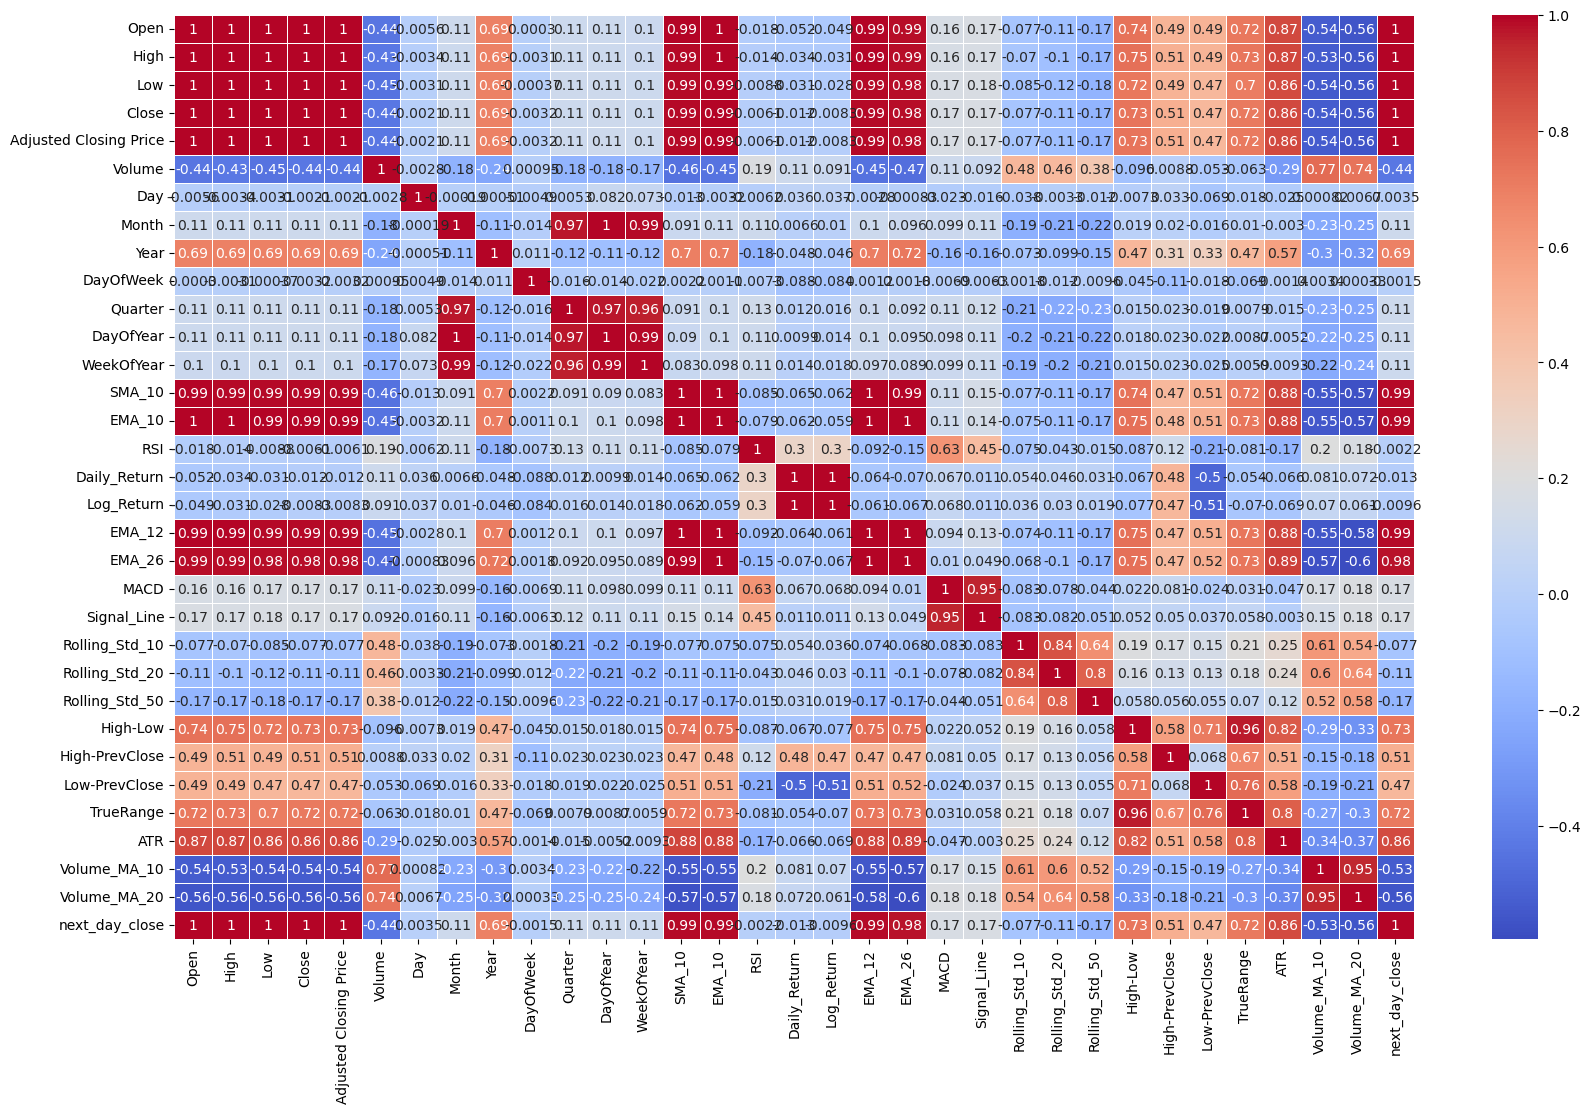

In [16]:
plt.figure(figsize=(20,12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

In [17]:
df.isna().sum()

Open                       0
High                       0
Low                        0
Close                      0
Adjusted Closing Price     0
Volume                     0
Day                        0
Month                      0
Year                       0
DayOfWeek                  0
Quarter                    0
DayOfYear                  0
WeekOfYear                 0
SMA_10                     9
EMA_10                     0
RSI                       13
Daily_Return               1
Log_Return                 1
EMA_12                     0
EMA_26                     0
MACD                       0
Signal_Line                0
Rolling_Std_10            10
Rolling_Std_20            20
Rolling_Std_50            50
High-Low                   0
High-PrevClose             1
Low-PrevClose              1
TrueRange                  0
ATR                       13
Volume_MA_10               9
Volume_MA_20              19
next_day_close             1
dtype: int64

In [18]:
cols = list(df.columns)

def values_imputation(df,cols):
    median_values = df[cols].median()
    filled = df[cols].fillna(median_values)
    return filled

df_na_filled = values_imputation(df,cols)

In [19]:
y = df_na_filled['next_day_close']
X2 = df_na_filled.drop('next_day_close',axis=1).copy()

## GPT Prompt for LinReg
We iteratively dropped the features with the highest VIF so can you now help me run the linear regression on the data I have?

In [20]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")


Training samples: 1055, Testing samples: 264


In [21]:
from sklearn.linear_model import LinearRegression

# Initialize and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Print coefficients
print("Model Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model Coefficients: [ 8.23187426e-02  9.16411215e-03 -4.20077771e-02  4.46428466e-01
  4.46463384e-01 -7.83021258e-09  9.21686318e-02 -8.05848357e-03
 -2.18539499e-01  2.88001335e-01  2.16730815e-01 -3.66133341e-03
  2.87514856e-02  5.64254546e-03 -2.07467698e+00  2.95976439e-02
  3.14881613e+02 -3.15307134e+02  1.79197681e+00  3.39754894e-01
  1.45222192e+00 -8.65232312e-01  1.66589790e+01 -3.29897447e+01
 -1.25211549e+00  5.11673664e-02  1.92868649e-01  1.42367536e-01
 -2.80949475e-01 -4.60220252e-02 -1.04940407e-08  2.43346817e-08]
Intercept: 436.98020313840004


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict on test set
y_pred_lr = model.predict(X_test)

# Compute evaluation metrics
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_lr)

# Print results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


Mean Absolute Error (MAE): 4.5809
Mean Squared Error (MSE): 47.5737
Root Mean Squared Error (RMSE): 6.8974
R² Score: 0.9956


## GPT Prompt for XGBoost Model
Can you show me how I could use the same data I have to feed it to an XGBoost model and evaluate its performance compared to the linear regression?

### XGBoost Model

In [23]:
import xgboost as xgb

# Initialize XGBoost regressor
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",  # Standard regression objective
    n_estimators=100,  # Number of trees
    learning_rate=0.1,  # Step size shrinkage
    max_depth=5,  # Depth of each tree (controls complexity)
    subsample=0.8,  # Fraction of samples used per tree
    colsample_bytree=0.8,  # Fraction of features per tree
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)


### LinReg vs XGB: Model Comparison

In [24]:
# Compute metrics for both models
models = {
    "Linear Regression": y_pred_lr,
    "XGBoost": y_pred_xgb
}

for model_name, y_pred in models.items():
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"🔹 {model_name} Performance:")
    print(f"   - Mean Absolute Error (MAE): {mae:.4f}")
    print(f"   - Mean Squared Error (MSE): {mse:.4f}")
    print(f"   - Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"   - R² Score: {r2:.4f}")
    print("-" * 50)


🔹 Linear Regression Performance:
   - Mean Absolute Error (MAE): 4.5809
   - Mean Squared Error (MSE): 47.5737
   - Root Mean Squared Error (RMSE): 6.8974
   - R² Score: 0.9956
--------------------------------------------------
🔹 XGBoost Performance:
   - Mean Absolute Error (MAE): 4.9206
   - Mean Squared Error (MSE): 57.3984
   - Root Mean Squared Error (RMSE): 7.5762
   - R² Score: 0.9947
--------------------------------------------------


## GPT Prompt for Grid Search
Can you write me a small bit of code to use grid search to fine tune the parameters of my XGBoost model? I want to see if I can improve the performance of the model just a bit more

In [25]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [250, 300, 350],  # Number of trees
    'learning_rate': [0.05, 0.1, 0.15],  # Step size shrinkage
    'max_depth': [3, 5, 7],  # Tree depth
    'subsample': [0.7, 0.8, 1.0],  # Fraction of samples per tree
    'colsample_bytree': [0.8, 0.9, 1.0]  # Fraction of features per tree
}

# Initialize the XGBoost regressor
xgb_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)

# Grid search with 3-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,  # 3-fold cross-validation
    scoring='r2',  # Optimize for R^2 score
    n_jobs=-1,  # Use all available cores
    verbose=1
)

# Fit Grid Search on training data
grid_search.fit(X_train, y_train)

# Print best parameters
print("Best Parameters:", grid_search.best_params_)

# Get best model
best_xgb = grid_search.best_estimator_

# Predict on test set
y_pred_xgb_tuned = best_xgb.predict(X_test)

# Evaluate tuned model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_xgb_tuned)
mse = mean_squared_error(y_test, y_pred_xgb_tuned)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_xgb_tuned)

# Print evaluation metrics
print(f"🔹 Tuned XGBoost Performance:")
print(f"   - Mean Absolute Error (MAE): {mae:.4f}")
print(f"   - Mean Squared Error (MSE): {mse:.4f}")
print(f"   - Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"   - R² Score: {r2:.4f}")


Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 250, 'subsample': 0.8}
🔹 Tuned XGBoost Performance:
   - Mean Absolute Error (MAE): 5.0396
   - Mean Squared Error (MSE): 58.8248
   - Root Mean Squared Error (RMSE): 7.6697
   - R² Score: 0.9946


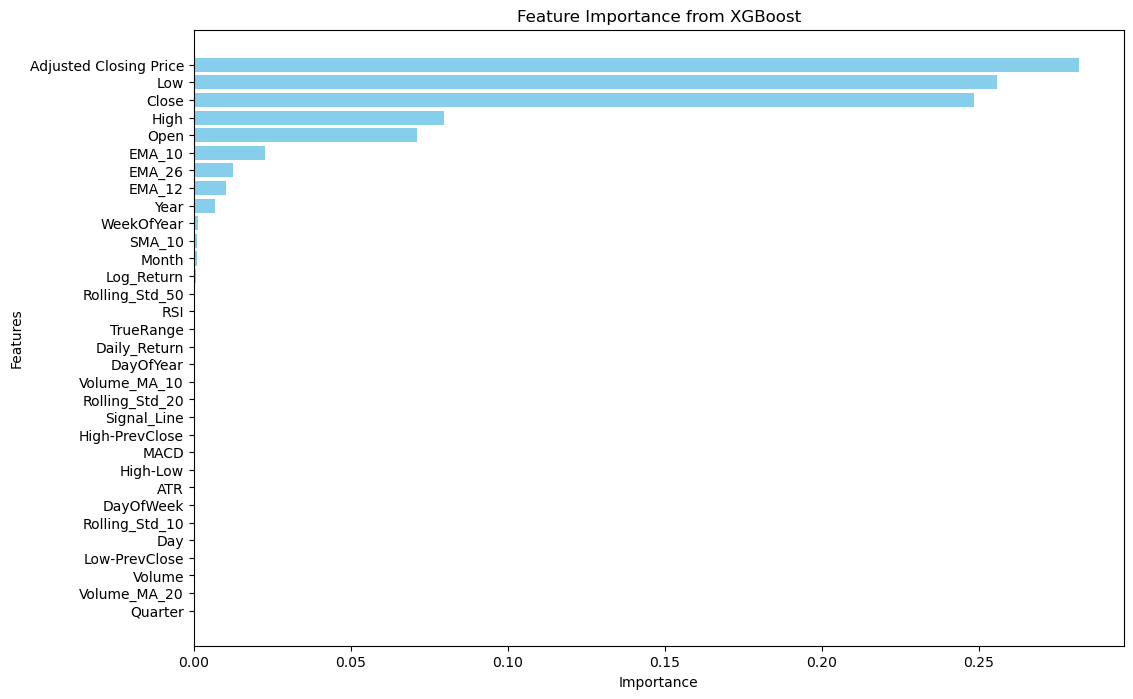

In [26]:
import matplotlib.pyplot as plt
import numpy as np

feature_importances = best_xgb.feature_importances_
feature_names = X_train.columns

importances_df = pd.DataFrame({
    'Features': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(importances_df['Features'], importances_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance from XGBoost')
plt.gca().invert_yaxis()
plt.show()



## Optimized XGBoost

In [27]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error


important_features = ['Adjusted Closing Price', 'Low', 'Close', 'High', 'Open', 'EMA_10', 'EMA_26', 'Year']
X_train_reduced = X_train[important_features]
X_test_reduced = X_test[important_features]

param_grid = {
    'n_estimators': [250, 300, 350],  # Number of trees
    'learning_rate': [0.05, 0.1, 0.15],  # Step size shrinkage
    'max_depth': [3, 5, 7],  # Tree depth
    'subsample': [0.7, 0.8, 1.0],  # Fraction of samples per tree
    'colsample_bytree': [0.8, 0.9, 1.0]  # Fraction of features per tree
}

model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='r2', verbose=1, n_jobs=-1)
grid_search.fit(X_train_reduced, y_train)

best_model = grid_search.best_estimator_
y_pred_train = best_model.predict(X_train_reduced)
y_pred_test = best_model.predict(X_test_reduced)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test)

print("Train Mean Squared Error:", mse_train)
print("Test Mean Squared Error:", mse_test)
print("Train R2 Score:", r2_train)
print("Test R2 Score:", r2_test)
print("Train MAPE:", mape_train)
print("Test MAPE:", mape_test)
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation R2 score:", grid_search.best_score_)


Fitting 3 folds for each of 243 candidates, totalling 729 fits
Train Mean Squared Error: 31.44889043453784
Test Mean Squared Error: 56.80342128226252
Train R2 Score: 0.9972118712322143
Test R2 Score: 0.9948005579969806
Train MAPE: 0.026664746334032558
Test MAPE: 0.03215596687555139
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 250, 'subsample': 0.7}
Best Cross-validation R2 score: 0.993357129677149


In [28]:
new_best_xgb = best_model

# Making the Prediction

In [29]:
df_to_pred = pymsimfin.get_share_prices('AMZN','2022-03-01','2024-03-31')

In [30]:
df_to_pred =df_to_pred.drop(columns=['Dividend Paid','Common Shares Outstanding'])
df_to_pred.rename(columns={
    'Opening Price':'Open', 'Highest Price':'High','Lowest Price':'Low','Last Closing Price':'Close','Trading Volume':'Volume'
    
},inplace=True)
df_to_pred['Date'] = pd.to_datetime(df_to_pred['Date'])
df_to_pred_original = df_to_pred.copy()

In [31]:
df_to_pred = transformation(df_to_pred)
df_to_pred.set_index('Ticker',inplace=True)

In [32]:
df_to_pred = values_imputation(df_to_pred,df_to_pred.columns)
df_to_pred.drop('Date',axis=1,inplace=True)


In [33]:
df_to_pred=df_to_pred[important_features]

In [34]:
df_to_pred

,Adjusted Closing Price,Low,Close,High,Open,EMA_10,EMA_26,Year
Ticker,,,,,,,,
AMZN,151.14,149.98,151.14,154.10,152.73,151.140000,151.140000,2022
AMZN,152.05,148.75,152.05,153.00,150.85,151.305455,151.207407,2022
AMZN,147.90,146.86,147.90,153.93,153.53,150.686281,150.962414,2022
AMZN,145.64,143.81,145.64,147.85,147.16,149.768775,150.568161,2022
AMZN,137.45,137.42,137.45,146.09,145.44,147.528998,149.596446,2022
...,...,...,...,...,...,...,...,...
AMZN,178.87,176.75,178.87,179.25,177.75,176.743082,173.969507,2024
AMZN,179.71,177.24,179.71,180.99,178.01,177.282522,174.394729,2024
AMZN,178.30,177.95,178.30,180.45,180.15,177.467518,174.684008,2024


In [35]:
predicted_prices = new_best_xgb.predict(df_to_pred)
df_to_pred_original['Predicted_Next_Day_Close'] = predicted_prices
df_to_pred_original = df_to_pred_original[['Date','Close','Predicted_Next_Day_Close',]]

In [36]:
df_to_pred_original.tail(15)

,Date,Close,Predicted_Next_Day_Close
508,2024-03-08,175.35,179.730469
509,2024-03-11,171.96,172.848984
510,2024-03-12,175.39,175.704575
511,2024-03-13,176.56,178.874557
512,2024-03-14,178.75,179.218323
513,2024-03-15,174.42,179.730469
514,2024-03-18,174.48,179.209656
515,2024-03-19,175.90,177.167496
516,2024-03-20,178.15,178.988647
517,2024-03-21,178.15,178.721603


In [37]:
next_day_of_period_price = df_to_pred_original.iloc[-1]['Predicted_Next_Day_Close']
last_day_period_current_price = df_to_pred_original.iloc[-1]['Close']


In [38]:
if next_day_of_period_price > last_day_period_current_price:
    print('Go long, buy shares ASAP (today) as the prices might rise, indicating profit momentum.')
    print('If you hold shares, keep them for potential gains as prices might keep rising')
elif next_day_of_period_price < last_day_period_current_price:
    print('Go short, prices expected to drop, consider short selling for potential profit.')
    print('If you hold shares, sell them now to avoid losses as prices might keep decreasing')


Go short, prices expected to drop, consider short selling for potential profit.
If you hold shares, sell them now to avoid losses as prices might keep decreasing
